In [16]:
# =========================
# 0. Install packages (Colab only)
# =========================
!pip install wandb scikit-learn pandas matplotlib joblib

# =========================
# 1. Mount Google Drive
# =========================
from google.colab import drive
drive.mount('/content/drive')

# =========================
# 2. Imports
# =========================
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import wandb
import joblib
import os

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


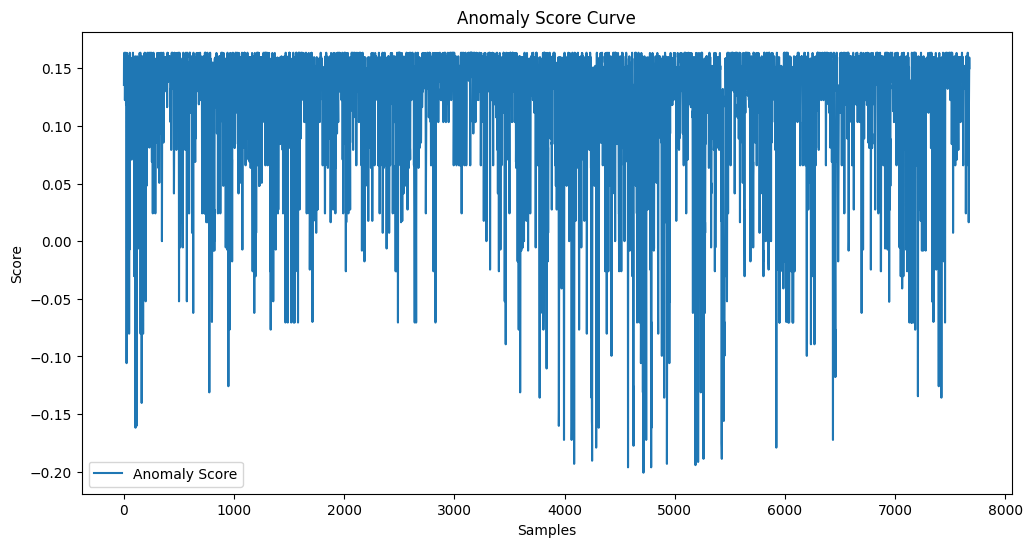

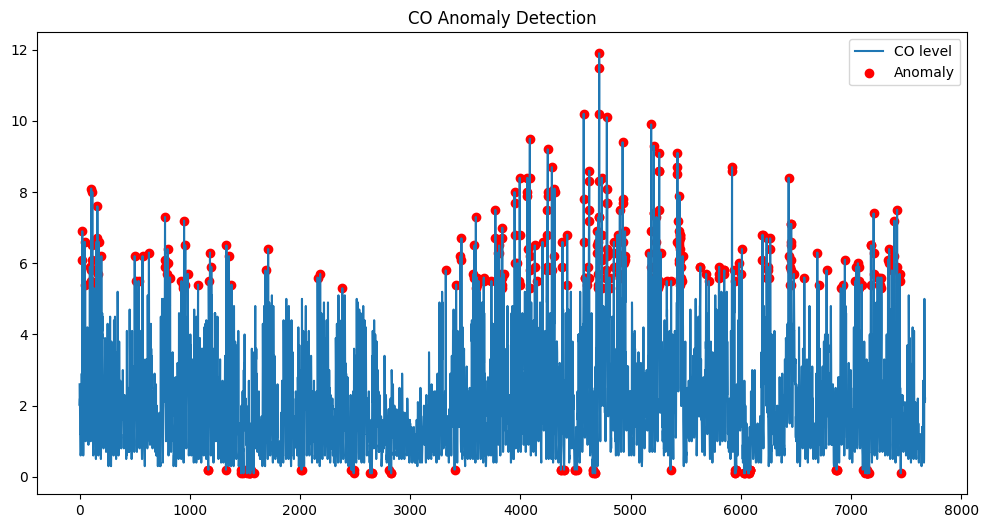

Accuracy: 0.9841021631482929
Precision: 0.7936507936507936
Recall: 0.872093023255814
✅ Model saved


Accuracy,▁
Precision,▁
Recall,▁
Accuracy,0.9841
Precision,0.79365
Recall,0.87209


In [18]:
# =========================
# 3. Paths
# =========================
DATA_PATH = "/content/drive/MyDrive/CO326/air_quality.csv"
SAVE_DIR = "/content/drive/MyDrive/CO326"

os.makedirs(SAVE_DIR, exist_ok=True)

# =========================
# 4. WandB
# =========================
wandb.login()  # safer

wandb.init(
    project="Fire detection",
    name="co-final-model"
)

# =========================
# 5. Load Dataset
# =========================
df = pd.read_csv(DATA_PATH, sep=';')
df = df.dropna(axis=1, how='all')

# =========================
# 6. Fix CO column
# =========================
df.rename(columns={"CO(GT)": "CO"}, inplace=True)

# Fix decimal format
df["CO"] = df["CO"].astype(str).str.replace(",", ".")
df["CO"] = pd.to_numeric(df["CO"], errors='coerce')

# =========================
# 7. Clean Data
# =========================
df = df[df["CO"] != -200]
df = df.dropna(subset=["CO"])
df = df.reset_index(drop=True)

# =========================
# 8. Feature
# =========================
X = df[["CO"]]

# =========================
# 9. Normalize
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 10. Train Model
# =========================
model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

model.fit(X_scaled)

# =========================
# 11. Predict
# =========================
df["anomaly"] = model.predict(X_scaled)
df["anomaly"] = df["anomaly"].map({1: 0, -1: 1})

# =========================
# 🔥 12. ANOMALY SCORE CURVE
# =========================
scores = model.decision_function(X_scaled)
df["score"] = scores

plt.figure(figsize=(12,6))
plt.plot(df["score"], label="Anomaly Score")
plt.title("Anomaly Score Curve")
plt.xlabel("Samples")
plt.ylabel("Score")
plt.legend()

score_plot = "/content/score_plot.png"
plt.savefig(score_plot)

wandb.log({"Anomaly Score Curve": wandb.Image(score_plot)})

plt.show()

# =========================
# 🔥 13. ANOMALY PLOT
# =========================
plt.figure(figsize=(12,6))

plt.plot(df["CO"], label="CO level")

plt.scatter(
    df.index[df["anomaly"] == 1],
    df["CO"][df["anomaly"] == 1],
    color="red",
    label="Anomaly"
)

plt.legend()
plt.title("CO Anomaly Detection")

anomaly_plot = "/content/anomaly_plot.png"
plt.savefig(anomaly_plot)

wandb.log({"Anomaly Plot": wandb.Image(anomaly_plot)})

plt.show()

# =========================
# 🔥 14. ACCURACY (Pseudo Labels)
# =========================
threshold = df["CO"].mean() + 2 * df["CO"].std()

df["true_label"] = (df["CO"] > threshold).astype(int)

acc = accuracy_score(df["true_label"], df["anomaly"])
prec = precision_score(df["true_label"], df["anomaly"])
rec = recall_score(df["true_label"], df["anomaly"])

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)

wandb.log({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec
})

# =========================
# 15. Save Model
# =========================
joblib.dump(model, f"{SAVE_DIR}/co_model.pkl")
joblib.dump(scaler, f"{SAVE_DIR}/scaler.pkl")

print("✅ Model saved")

# =========================
# 16. Finish WandB
# =========================
wandb.finish()